In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

In [132]:
coffee_production = pd.read_csv("total-production.csv").T

coffee_production.columns= coffee_production.iloc[0]

coffee_production.drop("total_production", inplace=True)

# Meshgrid - Single Figure Report on Brazil's Place in Global Coffee Market

* Create a Meshgrid Layout to combine our findings from our first project into a single report. 
* We want the two donut charts representing Brazil's production share in 1990 and 2018 in the top third of the figure. 
* The stackplot comparing Brazil to the rest of the world in the center of the figure. 
* In the bottom third a bar chart showing the total production of our top 5 countries, as well as a bar for other. Also include a pie chart showing the composition of the same data plotted in the bar chart. 
* Look up the country colors for our top 5 countries and color them accordingly. For 'other' category, color these grey.
* Consider setting rcParams to turn top and right borders off.
* Save the report out as an image.

In [133]:
coffee_production.head()

total_production,Angola,Bolivia (Plurinational State of),Brazil,Burundi,Ecuador,Indonesia,Madagascar,Malawi,Papua New Guinea,Paraguay,...,Panama,Sierra Leone,Sri Lanka,Thailand,Togo,Trinidad & Tobago,Uganda,Venezuela,Viet Nam,Yemen
1990,50.345,122.777,27285.6286,487.393,1503.815,7441.383,982.447,104.628,962.841,130.627,...,214.987,42.783,95.87,757.017,161.308,14.581,1955.009,1122.477,1310.288,0.0
1991,79.331,103.536,27293.4934,667.199,2123.824,8493.196,932.513,124.286,746.816,79.653,...,192.532,54.379,81.549,1468.936,432.652,17.792,2088.001,940.704,1437.848,0.0
1992,77.52,120.235,34603.3542,620.238,1185.48,5569.478,1121.684,137.161,900.111,54.291,...,196.978,39.084,53.181,1254.945,85.648,14.328,2185.074,1215.298,2340.447,0.0
1993,32.608,50.823,28166.9786,393.354,2069.007,6743.288,441.859,62.111,1019.481,70.046,...,142.066,37.451,53.79,1275.201,194.939,16.079,3141.706,1332.881,3020.216,0.0
1994,76.802,116.944,28192.047,664.143,2375.766,5367.878,641.372,84.112,1138.659,24.689,...,248.313,72.738,42.448,1399.135,176.296,18.435,2392.753,988.996,3631.609,0.0


In [134]:

axes_settings = {
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linestyle': '--',
    'axes.grid': True,
    'grid.color': 'grey',
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.figsize': (10, 6),
    'axes.titlesize': 20,
    'axes.titleweight': 'bold',
    'axes.titlepad': 15,
}

plt.rcParams.update(axes_settings)

### Data Prep

In [135]:
brazil_vs_others = pd.DataFrame({
    'Brazil': coffee_production['Brazil'].astype(float),
    'Other': coffee_production.drop(columns=['Brazil']).astype(float).sum(axis=1)
})

brazil_vs_others.head()

,Brazil,Other
1990,27285.6286,65944.431
1991,27293.4934,73973.191
1992,34603.3542,63922.545
1993,28166.9786,63597.643
1994,28192.0470,65121.147


In [136]:
melted = coffee_production.reset_index().melt(id_vars='index', var_name='Country', value_name='Production')
melted = melted.rename(columns={'index': 'Year'})
melted.head()

,Year,Country,Production
0,1990,Angola,50.345
1,1991,Angola,79.331
2,1992,Angola,77.52
3,1993,Angola,32.608
4,1994,Angola,76.802


In [137]:
coffee_production_2018= (
	melted[melted['Year'] == '2018']
	.groupby('Country')['Production']
	.sum()
    .sort_values(ascending=False)
)

coffee_production_2018_top5 = coffee_production_2018.iloc[:5]

coffee_production_2018_top5

Country
Brazil       62924.8836
Viet Nam     31174.0742
Colombia      13857.962
Indonesia     9417.5942
Ethiopia      7776.2234
Name: Production, dtype: object

In [138]:
coffee_production_rest_of_world = coffee_production_2018[5:].sum()

coffee_production_rest_of_world

45786.00029999999

In [139]:

rest_of_world_series = pd.Series([coffee_production_rest_of_world], index=['Rest of World'])

coffee_production_2018_top5_rest_of_world = pd.concat([coffee_production_2018_top5, rest_of_world_series])

coffee_production_2018_top5_rest_of_world

Brazil           62924.8836
Viet Nam         31174.0742
Colombia          13857.962
Indonesia         9417.5942
Ethiopia          7776.2234
Rest of World    45786.0003
dtype: object

In [140]:
pd.DataFrame(coffee_production_2018_top5_rest_of_world, columns=['2018'])

,2018
Brazil,62924.8836
Viet Nam,31174.0742
Colombia,13857.962
Indonesia,9417.5942
Ethiopia,7776.2234
Rest of World,45786.0003


### Meshgrid Layout

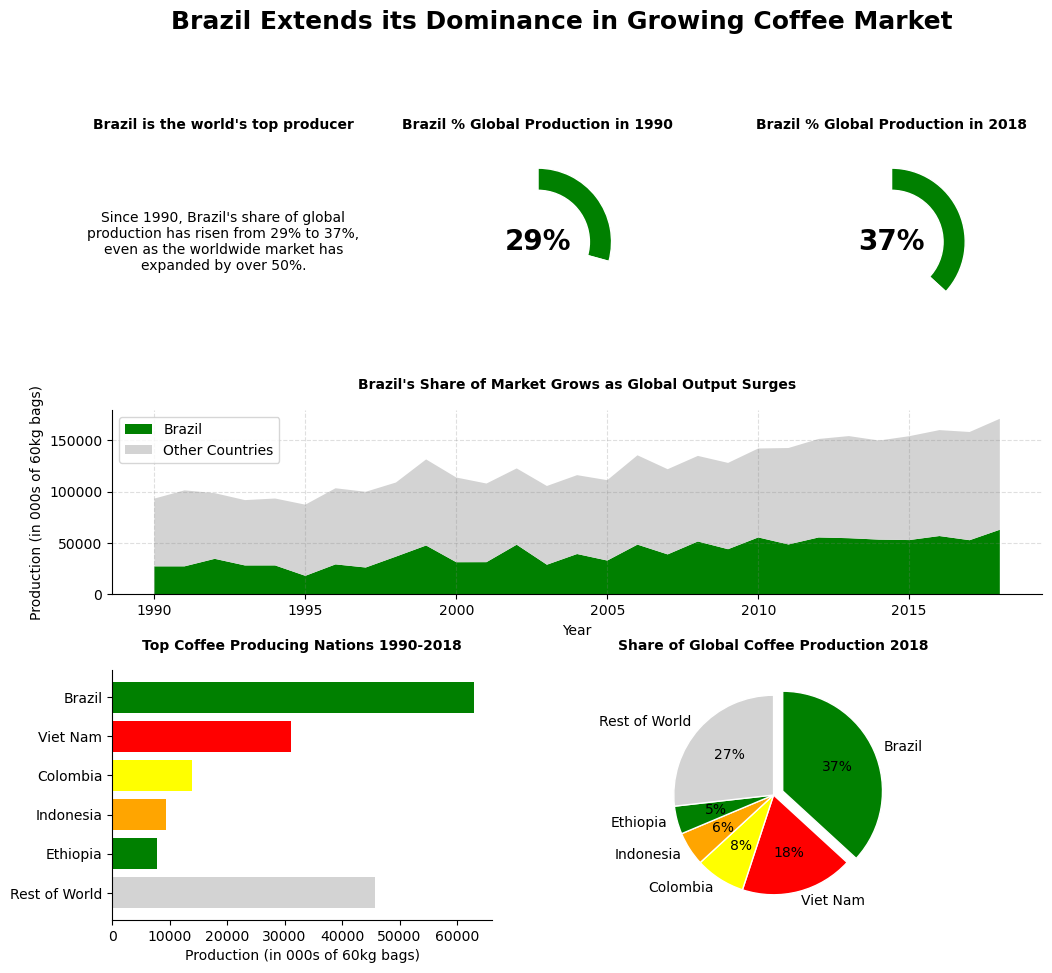

In [151]:
from numpy import who


fig = plt.figure(constrained_layout=True, figsize=(12,10))

grid = gridspec.GridSpec(ncols=12,nrows=12)
fig.suptitle("Brazil Extends its Dominance in Growing Coffee Market", fontsize=18, fontweight='bold', y=1.02)

# Defining all axes
ax=fig.add_subplot(grid[0:3, :3])
ax1=fig.add_subplot(grid[0:3, 4:7])
ax2=fig.add_subplot(grid[0:3, 8:])
ax3=fig.add_subplot(grid[4:7, :])
ax4=fig.add_subplot(grid[8:, :5])
ax5=fig.add_subplot(grid[8:, 5:])

# Chart 1 - Textual Chart
ax.clear()
ax.set_title("Brazil is the world's top producer", fontsize=10,pad=15)
ax.text(0.5, 0.5, 
        "Since 1990, Brazil's share of global\n"
        "production has risen from 29% to 37%,\n"
        "even as the worldwide market has\n"
        "expanded by over 50%.", 
        horizontalalignment='center', 
        verticalalignment='center', 
        fontsize=10,
        transform = ax.transAxes)
ax.axis('off')

# Pichart for 1990
ax1.axis('off')
ax1.set_title("Brazil % Global Production in 1990", fontsize=10,pad=15)
ax1.pie(
    brazil_vs_others.loc['1990'],
    #labels=['Brazil', 'Other Countries'],
    #autopct='%0.0f%%',
    colors=["green", "white"],
    pctdistance=0.85,
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white'}
)
whole_circle = plt.Circle((0,0), 0.7, color='white')
fig = plt.gcf()

# Adding Circle in Pie chart
ax1.add_artist(whole_circle)
ax1.text(
        0, 0, "29%", 
        horizontalalignment='center', 
        verticalalignment='center', 
        fontsize=20, 
        fontweight='bold'
)

# Adding Pie chart for 2018
ax2.axis('off')
ax2.set_title("Brazil % Global Production in 2018", fontsize=10,pad=15)
ax2.pie(
        brazil_vs_others.loc['2018'],
        #labels=['Brazil', 'Other Countries'],
        #autopct='%0.0f%%',
        colors=["green", "white"],
        pctdistance=0.85,
        startangle=90,
        counterclock=False,
        wedgeprops={'edgecolor': 'white'}
)

hole = plt.Circle((0,0), 0.7, color='white')
fig = plt.gcf()

# Adding Pie chart in the chart
ax2.add_artist(hole)
ax2.text(
        0, 0, "37%", 
        horizontalalignment='center', 
        verticalalignment='center', 
        fontsize=20, 
        fontweight='bold'
)

# Adding Stack plot for Brazil vs Others
ax3.set_title("Brazil's Share of Market Grows as Global Output Surges", fontsize=10,pad=15)
ax3.stackplot(  
    brazil_vs_others.index,
    brazil_vs_others['Brazil'],
    brazil_vs_others['Other'],
    labels=['Brazil', 'Other Countries'],
    colors=['green', 'lightgray']
)
ax3.set_xticks(brazil_vs_others.index[::5])
ax3.legend(loc='upper left')
ax3.set_ylabel("Production (in 000s of 60kg bags)")  
ax3.set_xlabel("Year")   

ax4.set_title("Top Coffee Producing Nations 1990-2018", fontsize=10,pad=15)
ax4.barh(
        coffee_production_2018_top5_rest_of_world[::-1].index,
        coffee_production_2018_top5_rest_of_world[::-1],
        color=['lightgray', 'green', 'orange', 'yellow', 'red', 'green']
)
ax4.grid(False)
ax4.set_xlabel('Production (in 000s of 60kg bags)')

ax5.axis('off')
ax5.set_title("Share of Global Coffee Production 2018", fontsize=10,pad=15)
ax5.pie(
        coffee_production_2018_top5_rest_of_world,
        labels=coffee_production_2018_top5_rest_of_world.index,
        autopct='%0.0f%%',
        colors=['green', 'red', 'yellow', 'orange', 'green', 'lightgray'],
        pctdistance=0.60,
        startangle=90,
        explode=[0.1,0,0,0,0,0],
        counterclock=False,
        wedgeprops={'edgecolor': 'white'}
)

plt.show()

# Subplots

* Read in `prices-paid-to-growers.csv` and create a subplot grid of histograms showing the distribution of prices paid to the countries Brazil, Colombia, Ethiopia, and one for all other nations.

In [152]:
prices_paid_to_growers = pd.read_csv("prices-paid-to-growers.csv").T.drop(9, axis=1)

prices_paid_to_growers.columns= prices_paid_to_growers.iloc[0]

prices_paid_to_growers.drop("prices_paid_to_growers", inplace=True)

prices_paid_to_growers["Other Nations"] =  prices_paid_to_growers.drop(["Colombia", "Brazil", "Ethiopia"], axis=1).mean(axis=1)

In [153]:
prices_paid_to_growers.head()

prices_paid_to_growers,Colombia,Dominican Republic,El Salvador,Guatemala,Honduras,India,Uganda,Brazil,Ethiopia,India,Togo,Uganda,Other Nations
1990,1.534724,1.458168,1.116194,1.204956,1.11147,1.473558,0.337598,1.199223,1.348565,0.978921,0.645267,0.166486,0.943624
1991,1.48179,1.382845,0.983322,1.270086,1.238947,1.358371,0.654322,0.97115,1.505322,0.897289,0.632307,0.26143,0.964325
1992,1.204656,1.027841,0.682322,0.888099,0.886057,1.191159,0.441397,0.997768,1.351128,0.877945,0.658494,0.197653,0.761219
1993,1.106477,1.172704,0.780397,0.914552,0.828746,1.278669,0.552298,1.167263,1.362442,0.975912,0.499857,0.259737,0.806986
1994,1.898327,2.478234,2.191177,1.662711,1.800576,1.73081,1.666651,2.52911,2.418234,1.246437,0.573784,0.919709,1.585565


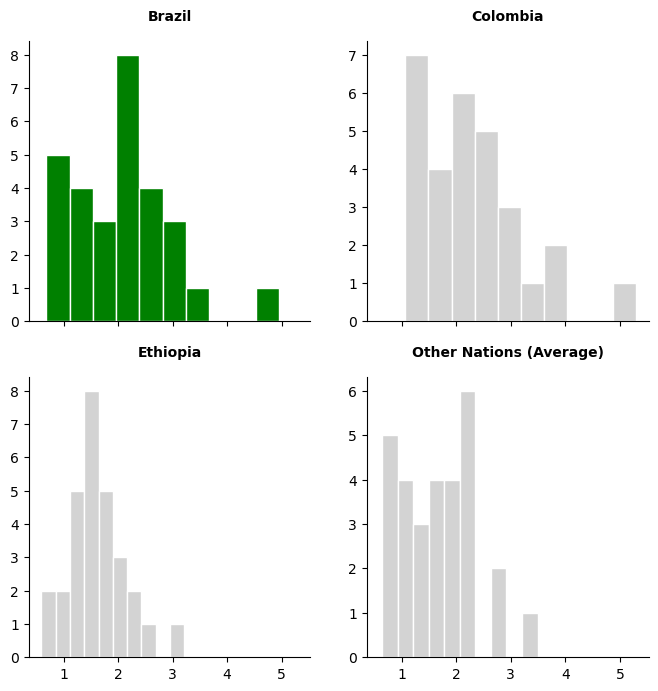

In [172]:
fig, ax = plt.subplots(2, 2, figsize=(8, 8), sharex=True)

ax[0][0].hist(
    prices_paid_to_growers["Brazil"], 
    #bins=20, 
    color='green', 
    edgecolor='white'
)
ax[0][0].set_title("Brazil", fontsize=10, pad=15)
ax[0][0].grid(False)

ax[0][1].hist(
    prices_paid_to_growers["Colombia"], 
    #bins=20, 
    color='lightgray',  # fixed color name
    edgecolor='white'
)
ax[0][1].set_title("Colombia", fontsize=10, pad=15)
ax[0][1].grid(False)

ax[1][0].hist(
    prices_paid_to_growers["Ethiopia"], 
    #bins=20, 
    color='lightgray', 
    edgecolor='white'
)
ax[1][0].set_title("Ethiopia", fontsize=10, pad=15)
ax[1][0].grid(False)

ax[1][1].hist(
    prices_paid_to_growers["Other Nations"], 
    #bins=20, 
    color='lightgray', 
    edgecolor='white'
)
ax[1][1].set_title("Other Nations (Average)", fontsize=10, pad=15)
ax[1][1].grid(False)    


plt.show()

(array([5., 4., 3., 4., 4., 6., 0., 2., 0., 1.]),
 array([0.63767231, 0.9229374 , 1.2082025 , 1.4934676 , 1.7787327 ,
        2.06399779, 2.34926289, 2.63452799, 2.91979308, 3.20505818,
        3.49032328]),
 <BarContainer object of 10 artists>)

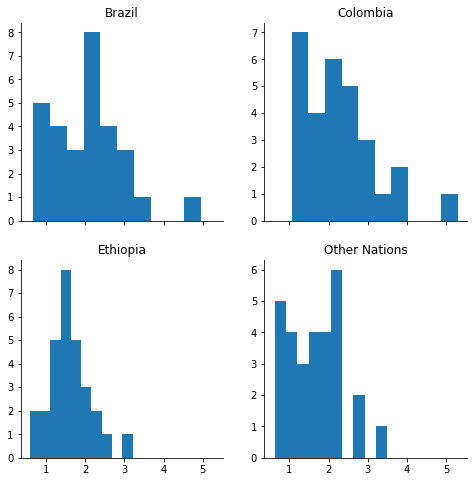